# oplanet examples notebook

This notebook demonstrates the main API with short explanations along the way.

It covers:
- Star name parsing and aliases
- Building an `OSystem`
- Reading returned values `[value, err_pos, err_neg]`
- Limit-only fallback `[nan, limit_upper, limit_lower]`
- Display helpers (`display`) and raw column inspection (`print_column`)

In [ ]:
import numpy as np
from oplanet import NSystem, parse_star_name, get_star_aliases, get_photometry_jy

## 1) Name parsing and aliases

The wrapper uses Simbad aliases so common star names can still resolve correctly.

In [2]:
target = "LHS 1140"
print("Parsed name:", parse_star_name(target))
aliases = get_star_aliases(target)
print("Number of aliases:", len(aliases))
print("First aliases:", aliases[:8])

Parsed name: LHS 1140
Number of aliases: 16
First aliases: ['GJ 3053', 'LHS 1140', 'TOI-256', '2MASS J00445930-1516166', 'TIC 92226327', 'Gaia DR3 2371032916186181760', 'CNS5 217', 'G 270-58']


## 2) Build an OSystem

`OSystem` loads the star and all known planets from the local NASA archive cache.

In [ ]:
system = NSystem(target)
print("System:", system.star_name)
print("Rows in dataframe:", len(system.df))
print("Number of planets:", system.n_planets)

System: LHS 1140
Rows in dataframe: 11
Number of planets: 2


## 3) Understanding returned values

Most numeric properties return a 3-value array:
- Normal case: `[value, err_pos, err_neg]`
- Limit-only case: `[nan, limit_upper, limit_lower]`

In [4]:
age = system.star.age_myr
dist = system.distance_pc

print("Age (Myr):", age)
print("Distance (pc):", dist)

def describe_triplet(name, arr):
    arr = np.asarray(arr, dtype=float)
    if np.isnan(arr[0]):
        print(f"{name}: no direct value; upper/lower limits = ({arr[1]}, {arr[2]})")
    else:
        print(f"{name}: value={arr[0]}, err_pos={arr[1]}, err_neg={arr[2]}")

describe_triplet("Star age", age)
describe_triplet("Distance", dist)

Age (Myr): [  nan   nan 5000.]
Distance (pc): [14.9861  0.0153 -0.0152]
Star age: no direct value; upper/lower limits = (nan, 5000.0)
Distance: value=14.9861, err_pos=0.0153, err_neg=-0.0152


## 4) Display helpers

Use `display()` for a readable summary and `print_column()` to inspect raw archive values.

In [5]:
# Pretty summaries
system.display()
system.star.display()
system.b.display()

[i] Looking at system properties
 > Star name:         LHS 1140
 > Number of planets: 2
 > Dataframe shape:   (11, 355)
 > Star:              <OStar(LHS 1140, 11 rows)>
 > Planets:           [<OPlanet(LHS 1140 c, 5 rows)>, <OPlanet(LHS 1140 b, 6 rows)>]
 > Distance (pc):     [14.9861  0.0153 -0.0152]
 > Parallax (mas):    [66.6996     0.0673611 -0.0673611]
[i] Star LHS 1140 properties:


 > Age (Myr):                       [  nan   nan 5000.]
 > Mass (solar masses):             [ 0.1844  0.0045 -0.0045]
 > Radius (solar radii):            [ 0.2159  0.003  -0.003 ]
 > Luminosity (solar luminosities): [-2.35556  0.01262 -0.01299]
 > Effective temperature (K):       [3216.   39.  -39.]
 > Metallicity (dex):               [-0.15  0.09 -0.09]
 > Spectral type:                   nan
[i] Planet LHS 1140 b properties:
 > Letter:                       b
 > Discovery year:               2017
 > Discovery method:             Transit
 > Orbital period (yrs):         [ 6.77267899e-02  4.65434634e-08 -4.65434634e-08]
 > Mass (Mjup):                  [ 0.01761957  0.00059781 -0.00059781]
 > Mass sin(i) (Mjup):           [ 0.01916128  0.00151025 -0.00147879]
 > Semi-major axis (AU):         [ 0.0946  0.0017 -0.0017]
 > Eccentricity:                 [  nan 0.043   nan]
 > Inclination (deg):            [ 8.986e+01  4.000e-02 -4.000e-02]
 > Argument of periastron (deg): [nan nan nan]
 > 

In [6]:
# Raw measurements for one archive column
system.print_column("st_age")

[i] Column st_age data:
    st_age  st_ageerr1  st_ageerr2  st_agelim
0      NaN         NaN         NaN        NaN
1      5.0         NaN         NaN       -1.0
2      5.0         NaN         NaN       -1.0
3      NaN         NaN         NaN        NaN
4      5.0         NaN         NaN       -1.0
5      NaN         NaN         NaN        NaN
6      5.0         NaN         NaN       -1.0
7      NaN         NaN         NaN        NaN
8      5.0         NaN         NaN       -1.0
9      5.0         NaN         NaN       -1.0
10     5.0         NaN         NaN       -1.0


## 5) Photometry convenience function

Get stellar flux density (Jy) at a requested wavelength in microns.

[#] Photometry for star LHS 1140 loaded from cache.
[~] Fitting spline to photometry... (0.000s)


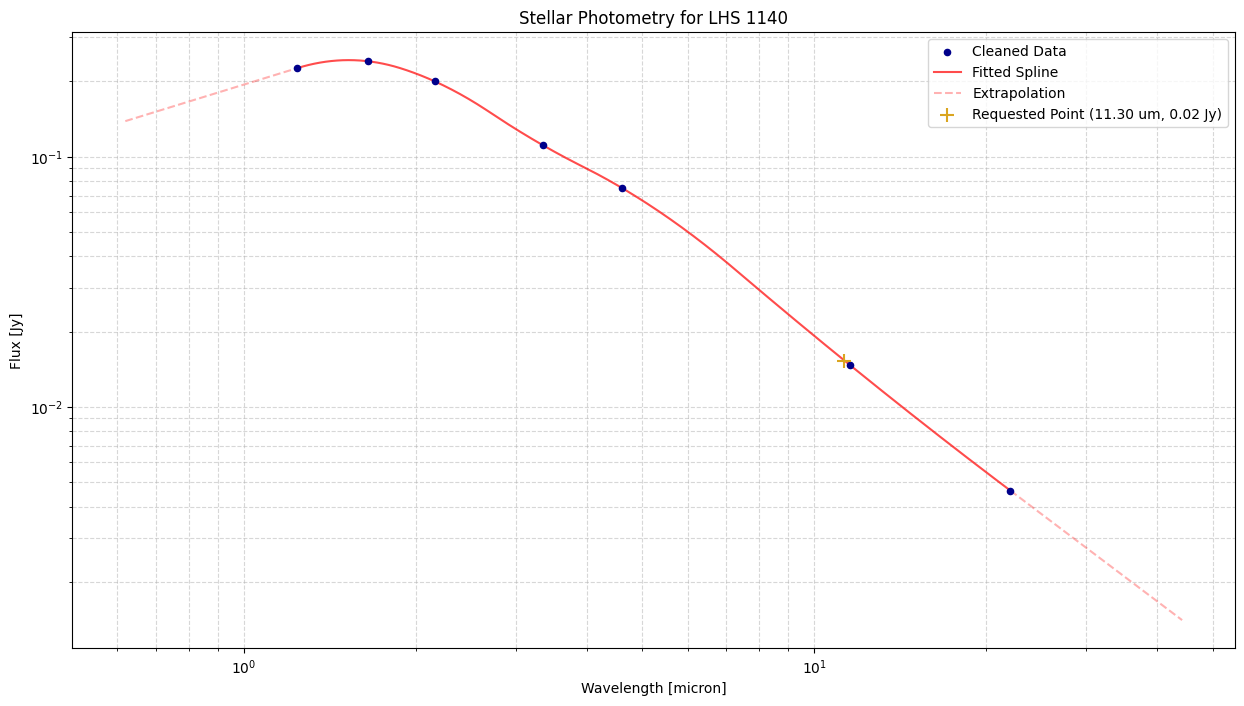

Flux at 11.56 um (Jy): 0.015331980200084411


In [7]:
flux_jy = get_photometry_jy(target, 11.3, show=True)
print("Flux at 11.56 um (Jy):", flux_jy)